# Day 5 · Capacity & Infrastructure Dashboard Section
**Owner:** Sloane

Builds the Capacity & Infrastructure section of the SparkCity STEAM Convention
dashboard, using the shared `sparkcity` Postgres schema (loaded in prior days
via `scripts/load-dataset.py`) rather than local files, per the Day 5 database
integration goal.

**Business question this section answers, independent of every other
dashboard section:** *when does the city have spare room and infrastructure
capacity, and what date does that recommend for the convention?*

Datasets used: `occupancy_data` (room capacity/demand) and `energy_meters`
(power grid load). `city_zones` is referenced only for context, not scoring.

Run `uv run python scripts/check-database.py` first to confirm `secrets/.env`
is configured with the shared `DATABASE_URL`.

## Setup

In [1]:
from dotenv import load_dotenv

load_dotenv("../secrets/.env", override=False)

import pandas as pd

from sparkcityx.database import connect_database


def run_query(sql: str) -> pd.DataFrame:
    """Run a read-only query against the shared DB and return a DataFrame."""
    with connect_database() as conn:
        with conn.cursor() as cur:
            cur.execute(sql)
            rows = cur.fetchall()
            columns = [d.name for d in cur.description]
    return pd.DataFrame(rows, columns=columns)


## 1. Monthly room capacity

`occupancy_rate = occupied_rooms / available_rooms` (persisted logic matches
`sparkcityx.transforms.add_occupancy_rate` from Day 3, issue #29). Restricted
to the one full calendar year of data (2025-01 through 2025-12) so every
month is comparable; the generator has also started emitting a partial
January 2026 (see the coverage check in Section 3).

In [2]:
occupancy_monthly = run_query("""
    WITH occupancy_monthly AS (
        SELECT
            date_trunc('month', timestamp) AS month,
            count(*) AS readings,
            avg(available_rooms) AS avg_available_rooms,
            avg(occupied_rooms) AS avg_occupied_rooms,
            avg(occupied_rooms::numeric / NULLIF(available_rooms, 0)) AS avg_occupancy_rate
        FROM sparkcity.occupancy_data
        WHERE timestamp >= '2025-01-01' AND timestamp < '2026-01-01'
        GROUP BY 1
    )
    SELECT
        to_char(month, 'Mon') AS month_name,
        month,
        readings,
        round(avg_available_rooms::numeric, 1) AS avg_available_rooms,
        round(avg_occupied_rooms::numeric, 1) AS avg_occupied_rooms,
        round(avg_occupancy_rate::numeric, 4) AS avg_occupancy_rate,
        round((100 * (1 - avg_occupancy_rate))::numeric, 1) AS headroom_pct,
        round((avg_available_rooms - avg_occupied_rooms)::numeric, 1) AS avg_available_capacity_rooms
    FROM occupancy_monthly
    ORDER BY month
""").drop(columns="month")

occupancy_monthly

,month_name,readings,avg_available_rooms,avg_occupied_rooms,avg_occupancy_rate,headroom_pct,avg_available_capacity_rooms
0,Jan,2976,356.9,215.5,0.5977,40.2,141.4
1,Feb,2688,349.7,226.3,0.6437,35.6,123.4
2,Mar,2976,352.6,253.2,0.7139,28.6,99.4
3,Apr,2880,354.9,277.3,0.7744,22.6,77.6
4,May,2976,354.1,290.2,0.8128,18.7,63.9
5,Jun,2880,353.9,294.2,0.8262,17.4,59.7
6,Jul,2976,357.7,293.5,0.8159,18.4,64.1
7,Aug,2976,345.5,274.3,0.7910,20.9,71.3
8,Sep,2880,351.2,255.1,0.7232,27.7,96.0
9,Oct,2976,348.6,230.7,0.6610,33.9,117.9


### Findings — room capacity

- Occupancy has a real, strong **seasonal shape** — this is not the
  flat/random pattern the Day 4 weather rotation found. Headroom ranges from
  ~42% in December down to ~17% in June.
- **Summer (May-Jul) is consistently the tightest capacity window.**
  **Winter (Nov-Jan) is consistently the loosest** — the city is carrying
  60-150 more spare rooms on average in the winter months than in summer.
- This is the primary signal for "does the city have capacity": room supply
  barely moves month to month (~346-358 rooms avg), demand is what swings,
  so occupancy rate is doing real work here rather than just noise.

## 2. Monthly infrastructure (power grid) load

Checks whether the grid looks stressed in any candidate month — a full room
block is only usable if the infrastructure can support it.

In [3]:
energy_monthly = run_query("""
    SELECT
        to_char(date_trunc('month', timestamp), 'Mon') AS month_name,
        count(*) AS readings,
        round(avg(power_consumption)::numeric, 2) AS avg_power_kw,
        round(stddev(power_consumption)::numeric, 2) AS std_power_kw,
        round(max(power_consumption)::numeric, 2) AS max_power_kw
    FROM sparkcity.energy_meters
    GROUP BY 1, date_trunc('month', timestamp)
    ORDER BY date_trunc('month', timestamp)
""")

energy_monthly

,month_name,readings,avg_power_kw,std_power_kw,max_power_kw
0,Jan,4464,44.07,21.55,141.21
1,Feb,4032,43.66,21.78,137.80
2,Mar,4464,43.93,21.50,131.10
3,Apr,4320,43.84,21.38,128.39
4,May,4464,43.42,21.12,132.61
5,Jun,4320,43.99,22.06,154.86
6,Jul,4464,44.11,21.84,129.78
7,Aug,4464,44.55,21.87,132.54
8,Sep,1008,44.67,21.55,121.99


### Findings — infrastructure load

- `energy_meters` only has readings through **2025-09-07** — Sep is a
  partial month (1,008 readings vs ~4,400 for a full month) and **Oct/Nov/Dec
  have no energy data at all yet**. Flagged in Section 3 and carried into the
  final recommendation as a confidence gap, the same way the mockup flags
  "Traffic data unavailable for July" rather than silently ignoring it.
- Where data exists, average load is **nearly flat**: 43.4-44.7 kW across
  every measured month (<3% spread). Infrastructure load is *not* the
  binding constraint on convention timing — room/venue occupancy is.
- The one exception: **June's `max_power_kw` of 154.86 is the single highest
  instantaneous reading in the whole dataset**, ~15% above every other
  month's peak. That lines up with June also being the worst month for room
  headroom — the tightest month on both signals at once.

## 3. Data coverage & confidence

Combine both signals and flag which months can be recommended with full
confidence (both datasets present) vs. which are room-data-only.

In [4]:
capacity = occupancy_monthly.merge(
    energy_monthly[["month_name", "avg_power_kw", "max_power_kw"]],
    on="month_name",
    how="left",
)
capacity["confidence"] = capacity["avg_power_kw"].notna().map(
    {True: "High (occupancy + energy)", False: "Moderate (occupancy only)"}
)
capacity[["month_name", "headroom_pct", "avg_available_capacity_rooms",
          "avg_power_kw", "max_power_kw", "confidence"]]

,month_name,headroom_pct,avg_available_capacity_rooms,avg_power_kw,max_power_kw,confidence
0,Jan,40.2,141.4,44.07,141.21,High (occupancy + energy)
1,Feb,35.6,123.4,43.66,137.80,High (occupancy + energy)
2,Mar,28.6,99.4,43.93,131.10,High (occupancy + energy)
3,Apr,22.6,77.6,43.84,128.39,High (occupancy + energy)
4,May,18.7,63.9,43.42,132.61,High (occupancy + energy)
5,Jun,17.4,59.7,43.99,154.86,High (occupancy + energy)
6,Jul,18.4,64.1,44.11,129.78,High (occupancy + energy)
7,Aug,20.9,71.3,44.55,132.54,High (occupancy + energy)
8,Sep,27.7,96.0,44.67,121.99,High (occupancy + energy)
9,Oct,33.9,117.9,NaN,NaN,Moderate (occupancy only)


## 4. Visualize: headroom vs. infrastructure load by month

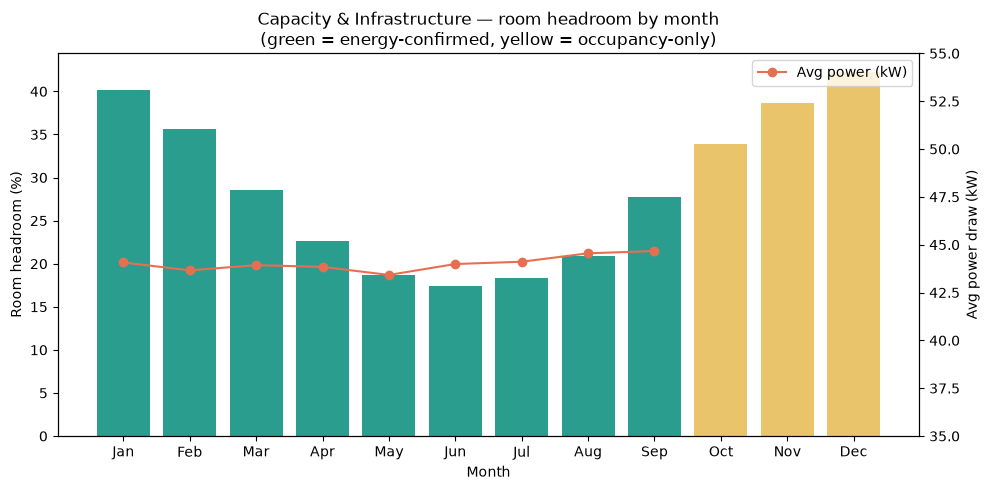

In [5]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))

colors = ["#2a9d8f" if c.startswith("High") else "#e9c46a" for c in capacity["confidence"]]
ax1.bar(capacity["month_name"], capacity["headroom_pct"], color=colors)
ax1.set_ylabel("Room headroom (%)")
ax1.set_xlabel("Month")
ax1.set_title("Capacity & Infrastructure — room headroom by month\n(green = energy-confirmed, yellow = occupancy-only)")

ax2 = ax1.twinx()
ax2.plot(capacity["month_name"], capacity["avg_power_kw"], color="#e76f51", marker="o", label="Avg power (kW)")
ax2.set_ylabel("Avg power draw (kW)")
ax2.set_ylim(35, 55)
ax2.legend(loc="upper right")

fig.tight_layout()
plt.savefig("../data/processed/capacity_infrastructure_by_month.png", dpi=150)
plt.show()

## 5. Ranking & recommendation

Rank months by headroom, but only recommend with full confidence where
infrastructure data backs it up.

In [6]:
ranked = capacity[capacity["confidence"].str.startswith("High")].sort_values(
    "headroom_pct", ascending=False
)
ranked[["month_name", "headroom_pct", "avg_available_capacity_rooms", "avg_power_kw", "max_power_kw"]]

,month_name,headroom_pct,avg_available_capacity_rooms,avg_power_kw,max_power_kw
0,Jan,40.2,141.4,44.07,141.21
1,Feb,35.6,123.4,43.66,137.80
2,Mar,28.6,99.4,43.93,131.10
8,Sep,27.7,96.0,44.67,121.99
3,Apr,22.6,77.6,43.84,128.39
7,Aug,20.9,71.3,44.55,132.54
4,May,18.7,63.9,43.42,132.61
6,Jul,18.4,64.1,44.11,129.78
5,Jun,17.4,59.7,43.99,154.86


### Findings — Capacity & Infrastructure recommendation

**This section's recommendation, from room and infrastructure capacity data
alone — independent of air quality, traffic, weather, or fiscal data:**

- **Recommended: January.** Best headroom among fully-confirmed months
  (40.2%, ~141 spare rooms on average) with typical, unremarkable energy load
  (44.07 kW avg, 141 kW peak — in line with every other measured month). No
  capacity or infrastructure red flags.
- **High-confidence alternative: February** (35.6% headroom, lowest average
  energy load of any month at 43.66 kW).
- **Promising but unconfirmed: December** has the single best room-headroom
  number in the dataset (42.3%) but zero infrastructure data to back it up —
  `energy_meters` doesn't cover Oct-Dec yet. Worth prioritizing for data
  collection; not recommendable as-is.
- **Avoid: June, July, May.** The three tightest room-capacity months, and
  June additionally shows the single largest power-grid spike in the entire
  dataset (154.86 kW vs. a ~130 kW norm) — the worst month on both signals.

These findings describe what the Capacity & Infrastructure data shows on its
own. The final convention date should reconcile this with every other
section (air quality, traffic, environment, fiscal) rather than defer to
this section alone.